In [1]:
!pip install langgraph

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
# now we will craete the dict as a state
class BMIstate(TypedDict):
  weight_kg: float
  height_m : float
  bmi: float
  category: str

In [15]:
# defining the bmi function.
def cal_bmi(state: BMIstate)-> BMIstate:
  weight = state['weight_kg']
  height = state['height_m']

  bmi = weight / (height ** 2)

  state['bmi'] = round(bmi, 2)

  return state

In [16]:
# defining the category function
def write_category(state: BMIstate)-> BMIstate:
  bmi = state['bmi']

  # decide the verdict
  if bmi < 18.5:
    state['category'] = 'underweight'
  elif 18.5 <= bmi < 25:
    state['category'] = 'normal_weight'
  elif 25 <= bmi < 30:
    state['category'] = 'overweight'
  else:
    state['category'] = 'obese'

  return state

In [17]:
# making the graph
graph  = StateGraph(BMIstate)

# creating the graph nodes
graph.add_node("calculating_bmi", cal_bmi)
graph.add_node("verdict_bmi", write_category)

# creating the edges of the graph
graph.add_edge(START, "calculating_bmi")
graph.add_edge("calculating_bmi", "verdict_bmi")
graph.add_edge("verdict_bmi", END)

In [18]:
# complining the graph
workflow = graph.compile()

In [35]:
# executing the graph
initial_state = {"weight_kg": 76, "height_m": 1.75}
output_state = workflow.invoke(initial_state)

In [36]:
print(output_state)

{'weight_kg': 76, 'height_m': 1.75, 'bmi': 24.82, 'category': 'normal_weight'}


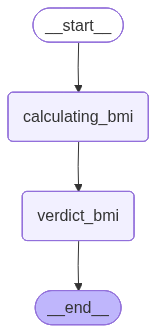

In [37]:
# printing the visual of this
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())